<a href="https://colab.research.google.com/github/prithikakalyan/buan3301/blob/main/Recommendation_Systems_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommendation Systems

Collaborative filtering is a popular technique for building recommendation systems. To get started, we will use the Goodreads dataset, which contains user ratings for books. We will be calcualting this lin algebra library.

# Load dataset

Connect your Google drive to access the data files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Description of dataset
**book_ratings.csv** contains ratings sorted by time. It looks like:

	user_id,book_id,rating
	1,258,5
	2,4081,4
	2,260,5
	2,9296,5
	2,2318,3

Ratings go from one to five. Both book IDs and user IDs are contiguous. For books, they are 1-10000, for users, 1-53424.

**books.csv** has metadata for each book (goodreads IDs, authors, title, average rating, etc.). The metadata have been extracted from goodreads XML files, available in `books_xml`.



Load the csv files in variables.

In [3]:
# Load the Goodbooks-10k dataset
books = pd.read_csv('/content/books.csv')
ratings = pd.read_csv('/content/book_ratings.csv')

# Looking into dataset

<span style="color: blue">Question: </span> Inspect first few rows in each dataset

#### ratings Dataset:



In [5]:
# Display the first few rows of the ratings dataset
ratings.head()


,user_id,book_id,rating
0,62,572,5
1,62,171,3
2,62,1041,4
3,62,701,4
4,74,582,5


### books Dataset

In [6]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


# Preprocessing

#### Missing Data:

<span style="color: blue">Question: </span> Check the column information and see if there are any missing values in these datasets.

In [7]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210004 entries, 0 to 210003
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  210004 non-null  int64
 1   book_id  210004 non-null  int64
 2   rating   210004 non-null  int64
dtypes: int64(3)
memory usage: 4.8 MB


In [8]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8690 entries, 0 to 8689
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    8690 non-null   int64  
 1   goodreads_book_id          8690 non-null   int64  
 2   best_book_id               8690 non-null   int64  
 3   work_id                    8690 non-null   int64  
 4   books_count                8690 non-null   int64  
 5   isbn                       8109 non-null   object 
 6   isbn13                     8184 non-null   float64
 7   authors                    8690 non-null   object 
 8   original_publication_year  8675 non-null   float64
 9   original_title             8202 non-null   object 
 10  title                      8690 non-null   object 
 11  language_code              8690 non-null   object 
 12  average_rating             8690 non-null   float64
 13  ratings_count              8690 non-null   int64

Fill missing values in 'original_title' with values from 'title'.

In [11]:
# Fill missing values in 'original_title' with values from 'title'
books['original_title'].fillna(books['title'], inplace=True)


/tmp/ipykernel_752/2454817616.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  books['original_title'].fillna(books['title'], inplace=True)


# Exploratory Data Analysis

Plot histogram of ratings

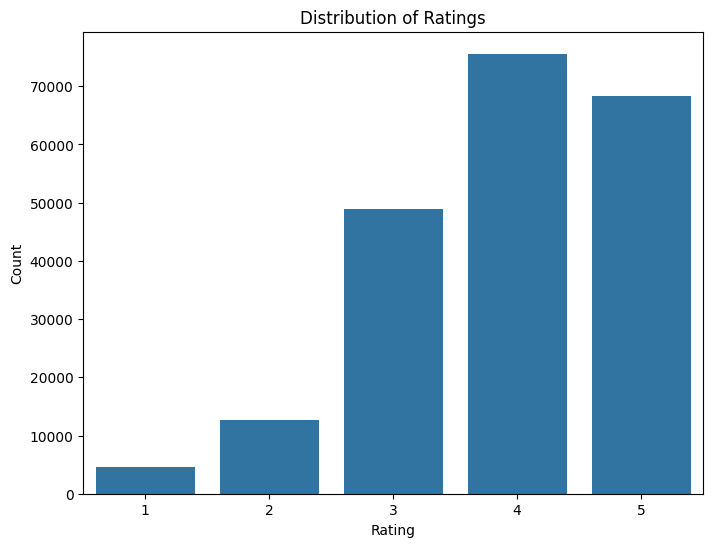

In [13]:
# Distribution of Ratings
plt.figure(figsize=(8, 6))
sns.countplot(data=ratings, x='rating')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Plot the histogram of ratings across users. Comment on the distribution you observe.

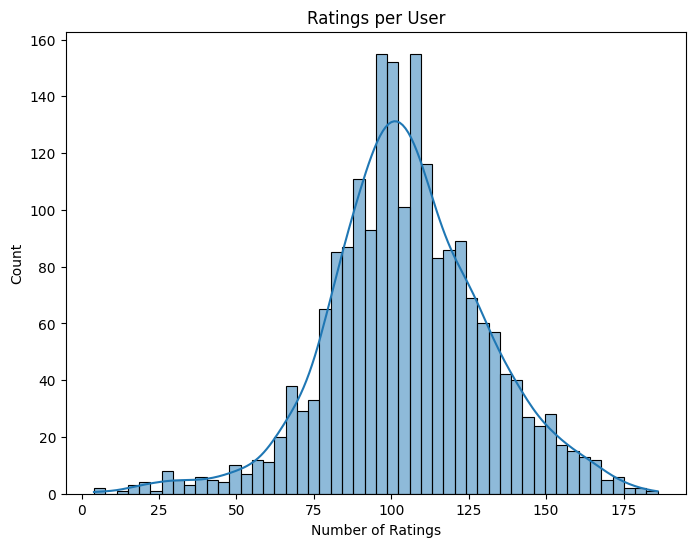

In [16]:
# Number of Ratings per User
user_ratings_count = ratings.groupby('user_id')['rating'].count()
plt.figure(figsize=(8, 6))
sns.histplot(user_ratings_count, bins=50, kde=True)
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Count')
plt.show()

What type of distribution do you see here?

Plot the histogram of ratings across books. Comment on the distribution you observe.

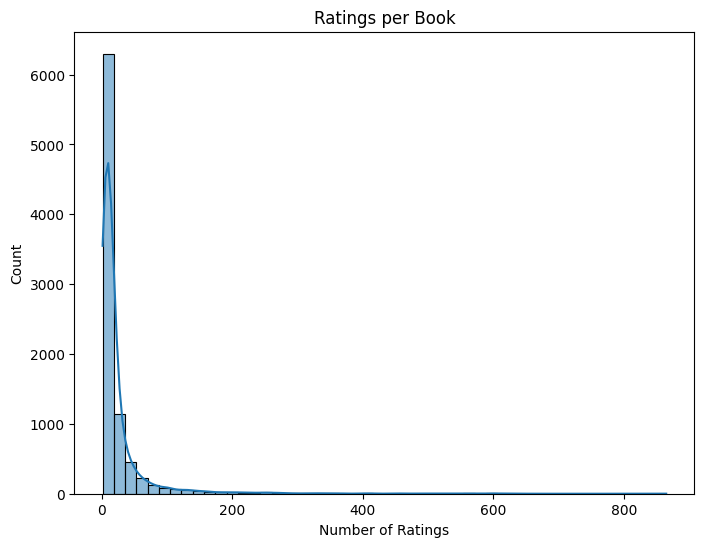

In [17]:
# Ratings per Book
book_ratings_count = ratings.groupby('book_id')['rating'].count()
plt.figure(figsize=(8, 6))
sns.histplot(book_ratings_count, bins=50, kde=True)
plt.title('Ratings per Book')
plt.xlabel('Number of Ratings')
plt.ylabel('Count')
plt.show()

What type of distribution do you see here?

# Recommendation using Singular Value Decomposition (SVD)

<span style="color: blue">Question: </span> Compute the minimum and maximum values of book_id and user_id.

In [18]:
ratings['book_id'].min(), ratings['book_id'].max(), ratings['user_id'].min(), ratings['user_id'].max()

(1, 9999, 62, 53414)

<span style="color: blue">Question: </span> Obtain the utility matrix of user book ratings, where users and books are along rows and columns, respectively.

In [19]:
# Sample DataFrame
t_data = ratings[['user_id', 'book_id', 'rating']]

# Pivot the DataFrame
pivoted_df_na = t_data.pivot(index='user_id', columns='book_id', values='rating')

print(pivoted_df_na.shape)

# Remove the index and column names
pivoted_df_na.index.name = None
pivoted_df_na.columns.name = None
pivoted_df_na = pivoted_df_na.dropna(axis=1, how='all')
pivoted_df = pivoted_df_na.fillna(0)
pivoted_df.head()

(2000, 8690)


,1,2,3,4,5,6,7,8,9,10,...,9989,9990,9991,9992,9993,9994,9995,9996,9997,9999
62,0.0,3.0,0.0,3.0,4.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74,5.0,4.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
109,0.0,0.0,0.0,5.0,1.0,0.0,0.0,3.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
149,0.0,0.0,0.0,5.0,3.0,0.0,0.0,5.0,4.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<span style="color: blue">Question: </span> Calculate singular value decomposition (SVD) of user-book ratings matrix.

In [20]:
from numpy.linalg import svd
matrix = pivoted_df.values
u, s, item_factor = svd(matrix, full_matrices=False)

# Calculate user factor by multiplying U and Sigma
# Set dimensions for sigma matrix
m = u.shape[0]
n = item_factor.shape[1]

# Initialize sigma matrix with zeros
sigma = np.zeros((m, m))

# Populate the diagonal elements of sigma with singular values from s
for i in range(min(m, n)):
    sigma[i, i] = s[i]
user_factor = np.dot(u, sigma)

<span style="color: blue">Question: </span> Check factorized matrix shapes. Shape represents number of rows and columns in a matrix.

In [21]:
user_factor.shape, item_factor.shape

((2000, 2000), (2000, 8690))

# Item-based collaborative filtering

function to calculate similarity across books.

In [22]:
import numpy as np
import operator
def cosine_similarity(x,y):
    return np.dot(x, y)/ (np.linalg.norm(x) * np.linalg.norm(y))

def similar_books(book_id,item_factor,n_elements):
    similarity = {}
    vh2=item_factor[:n_elements, :]
    print(vh2.shape)
    for col in range(0,vh2.shape[1]):
        similarity[col] = cosine_similarity(vh2[:,book_id], vh2[:,col])
    return similarity

<span style="color:

1.   List item
2.   List item

blue">Question: </span> Find the top-5 most similar books for book_id=62

In [23]:
bid = 62
book_info = books[books['book_id'] == bid]
if not book_info.empty:
  print("Book we are interested in:")
  title = book_info['title'].values[0]
  authors = book_info['authors'].values[0]
  print(f"Title: {title}")
  print(f"Authors: {authors}")

number_of_elements = 5
book_predictions=similar_books(1,item_factor, number_of_elements)
recommendations = [(book_id, sim) for book_id, sim in book_predictions.items() if book_id != bid]
recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)
number_of_recommendations = 6
top_5_recommendations = recommendations[:number_of_recommendations]
# print(top_5_recommendations)
print("Top-5 Recommendations")
for book_id, similarity in top_5_recommendations:
    book_info = books[books['book_id'] == book_id]
    if not book_info.empty:
        title = book_info['title'].values[0]
        authors = book_info['authors'].values[0]
        print(f"Title: {title}")
        print(f"Authors: {authors}")
    else:
        print(f"Book ID {book_id} not found in the books dataset.\n")

Book we are interested in:
Title: The Golden Compass (His Dark Materials, #1)
Authors: Philip Pullman
(5, 8690)
Top-5 Recommendations
Title: The Hunger Games (The Hunger Games, #1)
Authors: Suzanne Collins
Title: Shadow and Bone (Shadow and Bone, #1)
Authors: Leigh Bardugo
Title: When Will There Be Good News? (Jackson Brodie, #3)
Authors: Kate Atkinson
Title: Brother Odd (Odd Thomas, #3)
Authors: Dean Koontz
Title: The Undomestic Goddess
Authors: Sophie Kinsella
Title: The Twelve Tribes of Hattie
Authors: Ayana Mathis


# User-based collaborative filtering

Function to calculate similar users for a given focal user

In [24]:
# User-based collaborative filtering function
def similar_users(user_id, u1, n_elements=5):
    # Create a dictionary to store similarity scores
    similarity_dict = {}

    # Extract the first n_elements from u1
    u2 = u1[:, :n_elements]

    # Iterate over each user (column) in u2
    for col in range(0, u2.shape[0]):
        # Calculate cosine similarity between the user_id's row and the current user's row
        similarity_dict[col] = cosine_similarity(u2[user_id, :], u2[col, :])

    # Return the dictionary of similarity scores
    return similarity_dict

Identify the most similar user to user with id=1 in terms of their reading preferences

In [25]:
# Specify a user ID for which you want to make recommendations
uid = 1

# Compute similar users for the specified user (uid)
user_predictions = similar_users(uid, user_factor, 20)

# Sort similar users by similarity score in descending order
sim_user = [(user_id, sim) for user_id, sim in user_predictions.items() if user_id != uid]
sim_user = sorted(sim_user, key=lambda x: x[1], reverse=True)
print(sim_user)





[(964, np.float64(0.8755267299542091)), (1031, np.float64(0.8738047195391073)), (1203, np.float64(0.8656046276435381)), (950, np.float64(0.8622402233674901)), (1182, np.float64(0.8597325331233268)), (401, np.float64(0.8567182030809103)), (490, np.float64(0.8514949029764858)), (457, np.float64(0.8493468834828444)), (1107, np.float64(0.8458434294260826)), (387, np.float64(0.842874807298544)), (399, np.float64(0.8423606001758965)), (1285, np.float64(0.8423468438264741)), (609, np.float64(0.8375752728039295)), (764, np.float64(0.8314866209621605)), (1277, np.float64(0.8284200768148984)), (390, np.float64(0.8264179800397904)), (487, np.float64(0.8235138953085747)), (1843, np.float64(0.8230541211675935)), (1838, np.float64(0.819529181031772)), (1891, np.float64(0.8162348658337111)), (968, np.float64(0.8130262974508788)), (403, np.float64(0.8080239238727536)), (727, np.float64(0.8064365777475853)), (1150, np.float64(0.8035034493663021)), (1508, np.float64(0.8030727272533754)), (1581, np.float

Check: Do these users have similar ratings across the books that both of them have read?

In [26]:
# Get the most similar user's user ID
most_similar_user_id = sim_user[0][0]

# Get the corresponding user IDs from the pivoted DataFrame
user_id_1 = pivoted_df.index[most_similar_user_id]
user_id_2 = pivoted_df.index[1]

# Extract unique book IDs rated by each user
books_user1 = t_data[t_data['user_id'] == user_id_1]['book_id'].unique()
books_user2 = t_data[t_data['user_id'] == user_id_2]['book_id'].unique()

# Find books rated by user 2 and user 1
common_books = set(books_user2).intersection(set(books_user1))
print("common books: ",len(common_books))
ratings_focal_user = []
ratings_similar_user = []
for bidx in common_books:
  ratings_focal_user.append(t_data[(t_data['user_id'] == user_id_1) & (t_data['book_id'] == bidx)].rating)
  ratings_similar_user.append(t_data[(t_data['user_id'] == user_id_2) & (t_data['book_id'] == bidx)].rating)

print("average rating of user 1", np.mean(ratings_focal_user))
print("average rating of similar user:", np.mean(ratings_similar_user))

# from scipy.stats import pearsonr
# pearsonr(ratings_focal_user, ratings_similar_user)


common books:  15
average rating of user 1 4.466666666666667
average rating of similar user: 3.8666666666666667


What are the top book liked by user-1?

In [27]:
# Calculate the top books liked by user - 1
common_book_ratings = {}
for bidx in common_books:
    common_book_ratings[bidx] = t_data[(t_data['user_id'] == user_id_1) & (t_data['book_id'] == bidx)]["rating"].values[0]

# print(common_book_ratings)
# Sort probable books by mean rating in descending order
common_book_ratings = sorted(common_book_ratings.items(), key=lambda x: x[1], reverse=True)

# # Get the top 5 book recommendations with ratings above 3.5
top_5_books_read = [book_info for book_info in common_book_ratings if book_info[1] > 3.5][:5]

# # Print the top 5 book recommendations along with their titles and authors
for book_id, rating in top_5_books_read:
    book_info = books[books['book_id'] == book_id]
    if not book_info.empty:
        title = book_info['title'].values[0]
        authors = book_info['authors'].values[0]
        print(f"Title: {title}")
        print(f"Authors: {authors}")
    else:
        print(f"Book ID {book_id} not found in the books dataset.")

Title: The Hunger Games (The Hunger Games, #1)
Authors: Suzanne Collins
Title: Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
Authors: J.K. Rowling, Mary GrandPré
Title: Divergent (Divergent, #1)
Authors: Veronica Roth
Title: Catching Fire (The Hunger Games, #2)
Authors: Suzanne Collins
Title: Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)
Authors: J.K. Rowling, Mary GrandPré, Rufus Beck


Recommending books to User-1 using the preferences of its closest user.

Use the average rating of the books that are read by user-2 but not by user-1 to form reccommendations.

In [28]:
# Find books rated by user 2 but not by user 1 - use ratings by all the users to recommend
probable_books = set(books_user2) - set(books_user1)

# Calculate the mean rating for each probable book
probable_book_ratings = {}
for book_id in probable_books:
    probable_book_ratings[book_id] = np.mean(t_data[t_data['book_id'] == book_id]['rating'])

# Sort probable books by mean rating in descending order
book_recommendations = sorted(probable_book_ratings.items(), key=lambda x: x[1], reverse=True)

# Get the top 5 book recommendations with ratings above 3.5
top_5_recommendations = [book_info for book_info in book_recommendations if book_info[1] > 3.5][:5]

# Print the top 5 book recommendations along with their titles and authors
for book_id, rating in top_5_recommendations:
    book_info = books[books['book_id'] == book_id]
    if not book_info.empty:
        title = book_info['title'].values[0]
        authors = book_info['authors'].values[0]
        print(f"Title: {title}")
        print(f"Authors: {authors}")
    else:
        print(f"Book ID {book_id} not found in the books dataset.")


Title: The Blind Owl
Authors: Sadegh Hedayat, D.P. Costello
Title: Nine Stories
Authors: J.D. Salinger
Title: Harry Potter and the Chamber of Secrets (Harry Potter, #2)
Authors: J.K. Rowling, Mary GrandPré
Title: Steve Jobs
Authors: Walter Isaacson
Title: The Girl Who Played with Fire (Millennium, #2)
Authors: Stieg Larsson, Reg Keeland


Comment on the results.

Recommending books to User-1 using the preferences of its closest user.

Rely only on user-2 ratings to form reccommendations.

In [29]:
# Find books rated by user 2 but not by user 1 - just use the ratings by user 2 to recommend
probable_books = set(books_user2) - set(books_user1)

# Calculate the mean rating for each probable book
probable_book_ratings = {}
for book_id in probable_books:
    probable_book_ratings[book_id] = t_data[(t_data['user_id'] == user_id_2) & (t_data['book_id'] == book_id)]['rating'].values[0]

# Sort probable books by mean rating in descending order
book_recommendations = sorted(probable_book_ratings.items(), key=lambda x: x[1], reverse=True)

# Get the top 5 book recommendations with ratings above 3.5
top_5_recommendations = [book_info for book_info in book_recommendations if book_info[1] > 3.5][:5]

# Print the top 5 book recommendations along with their titles and authors
for book_id, rating in top_5_recommendations:
    book_info = books[books['book_id'] == book_id]
    if not book_info.empty:
        title = book_info['title'].values[0]
        authors = book_info['authors'].values[0]
        print(f"Title: {title}")
        print(f"Authors: {authors}")
    else:
        print(f"Book ID {book_id} not found in the books dataset.")


Title: The Girl Who Kicked the Hornet's Nest (Millennium, #3)
Authors: Stieg Larsson, Reg Keeland
Title: Animal Farm
Authors: George Orwell
Title: The Girl with the Dragon Tattoo (Millennium, #1)
Authors: Stieg Larsson, Reg Keeland
Title: Foundation (Foundation #1)
Authors: Isaac Asimov
Title: Master of the Game
Authors: Sidney Sheldon


Comment on the results.

# Conclusion

This tutorial showcases a toy example of how to use a simple matrix decomposition method to recommend products, which in turn increases their engagement on the platform. Alternately, this toy example provides a method for how the platform can efficiently relay the information to the users, to answer whether we should look at: 'what do people like me read?' or 'what people prefer to read in general?'